# Лабораторная 1: классификация цвета автомобиля

Классификация цвета автомобиля на фронтальных изображениях DVM-CAR.

In [1]:
from pathlib import Path
import json
import subprocess
import sys

import pandas as pd
import matplotlib.pyplot as plt
import torch
from PIL import Image
from IPython.display import Image as DisplayImage, display

ROOT = Path.cwd()
if ROOT.name != "lab1":
    ROOT = ROOT / "lab1"

print("Project root:", ROOT)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


Project root: T:\itmo\cv\cv_labs\lab1
CUDA available: True
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


## 1. Подготовленный датасет

In [2]:
summary = json.loads((ROOT / "data/dvm_front/summary.json").read_text(encoding="utf-8"))
summary

{'images_root': 'T:\\itmo\\cv\\lab1\\data\\confirmed_fronts',
 'num_classes': 13,
 'classes': {'Beige': 0,
  'Black': 1,
  'Blue': 2,
  'Bronze': 3,
  'Brown': 4,
  'Green': 5,
  'Grey': 6,
  'Orange': 7,
  'Purple': 8,
  'Red': 9,
  'Silver': 10,
  'White': 11,
  'Yellow': 12},
 'num_train': 41814,
 'num_val': 8960,
 'num_test': 8961,
 'class_counts': {'Beige': 600,
  'Black': 14316,
  'Blue': 8483,
  'Bronze': 329,
  'Brown': 911,
  'Green': 777,
  'Grey': 9472,
  'Orange': 559,
  'Purple': 362,
  'Red': 6094,
  'Silver': 7770,
  'White': 9395,
  'Yellow': 667}}

In [3]:
pd.DataFrame(
    [
        {"split": "train", "images": summary["num_train"]},
        {"split": "validation", "images": summary["num_val"]},
        {"split": "test", "images": summary["num_test"]},
    ]
)

,split,images
0,train,41814
1,validation,8960
2,test,8961


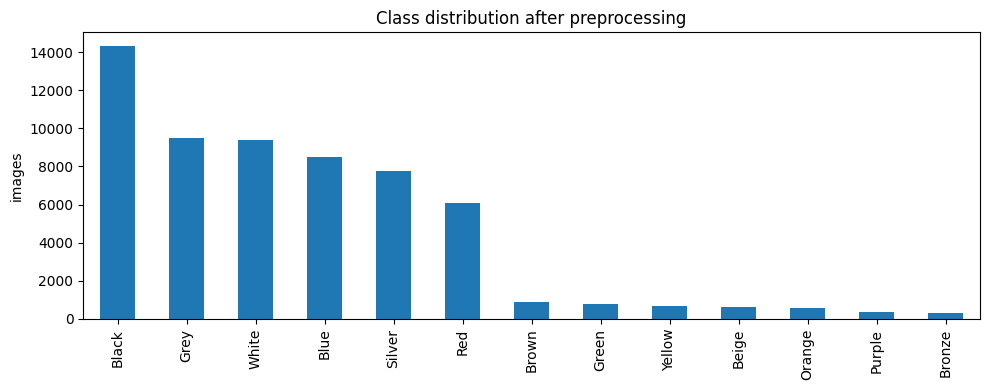

In [4]:
class_counts = pd.Series(summary["class_counts"]).sort_values(ascending=False)
class_counts.plot(kind="bar", figsize=(10, 4), title="Class distribution after preprocessing")
plt.ylabel("images")
plt.tight_layout()
plt.show()

## 2. Примеры из тестовой выборки

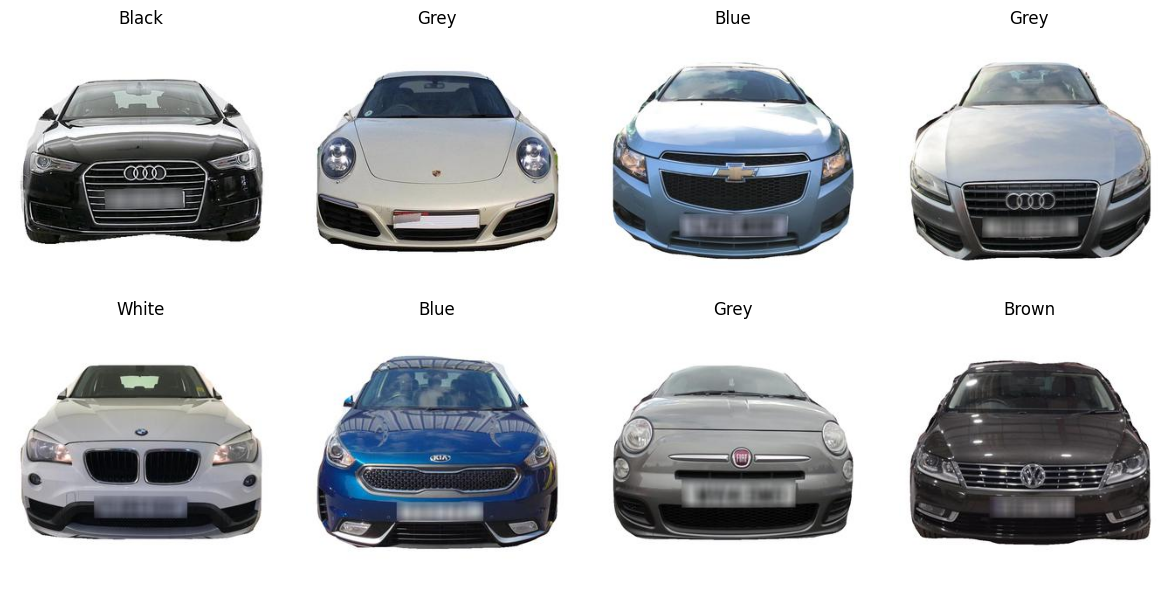

In [5]:
def resolve_image_path(path, images_root):
    path = Path(path)
    if path.exists():
        return path
    if "confirmed_fronts" in path.parts:
        idx = path.parts.index("confirmed_fronts")
        candidate = images_root.joinpath(*path.parts[idx + 1:])
        if candidate.exists():
            return candidate
    return path

images_root = ROOT / "data/confirmed_fronts"
test_df = pd.read_csv(ROOT / "data/dvm_front/test.csv")
test_df["path"] = test_df["path"].map(lambda p: str(resolve_image_path(p, images_root)))
test_df = test_df[test_df["path"].map(lambda p: Path(p).exists())].reset_index(drop=True)
sample_df = test_df.sample(8, random_state=7)

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for ax, (_, row) in zip(axes.ravel(), sample_df.iterrows()):
    ax.imshow(Image.open(row["path"]).convert("RGB"))
    ax.set_title(row["label"])
    ax.axis("off")
plt.tight_layout()
plt.show()

## 3. Метрики трех моделей

In [6]:
training_type = {
    "scratch_resnet": "from scratch",
    "resnet18": "ImageNet + fine-tuning",
    "mobilenet_v3_small": "ImageNet + fine-tuning",
}

rows = []
for model_name in ["scratch_resnet", "resnet18", "mobilenet_v3_small"]:
    metrics = json.loads((ROOT / f"runs/{model_name}/metrics.json").read_text(encoding="utf-8"))
    rows.append(
        {
            "Model": model_name,
            "Training type": training_type[model_name],
            "Best val F1_macro": round(metrics["best_val_f1_macro"], 4),
            "Test F1_macro": round(metrics["test"]["f1_macro"], 4),
            "Test loss": round(metrics["test"]["loss"], 4),
        }
    )

metrics_df = pd.DataFrame(rows).sort_values("Test F1_macro", ascending=False)
metrics_df


,Model,Training type,Best val F1_macro,Test F1_macro,Test loss
1,resnet18,ImageNet + fine-tuning,0.8141,0.8085,0.7741
2,mobilenet_v3_small,ImageNet + fine-tuning,0.8031,0.8044,1.0988
0,scratch_resnet,from scratch,0.7067,0.7111,0.7588


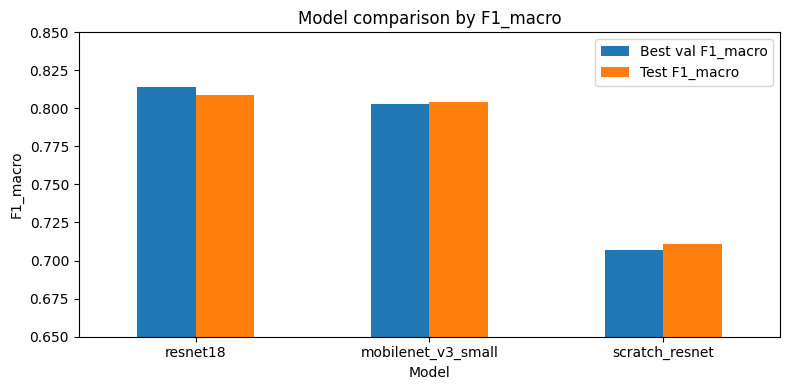

In [7]:
metrics_df.plot(
    x="Model",
    y=["Best val F1_macro", "Test F1_macro"],
    kind="bar",
    figsize=(8, 4),
    ylim=(0.65, 0.85),
    title="Model comparison by F1_macro",
)
plt.ylabel("F1_macro")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 4. Графики обучения

scratch_resnet


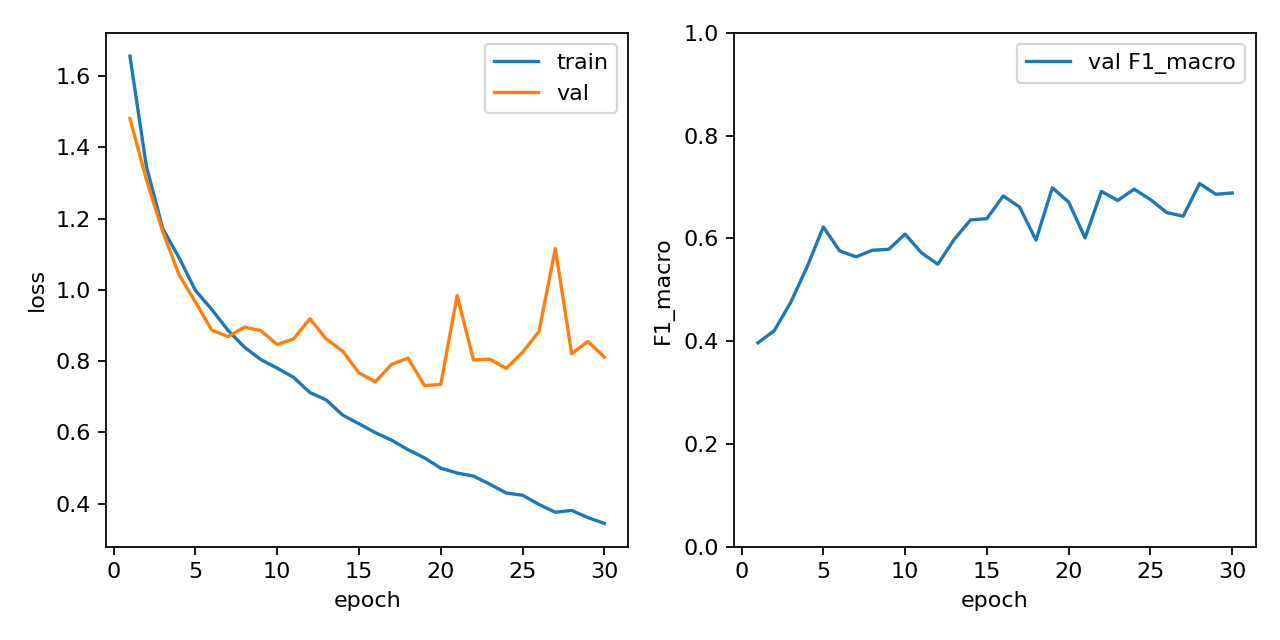

resnet18


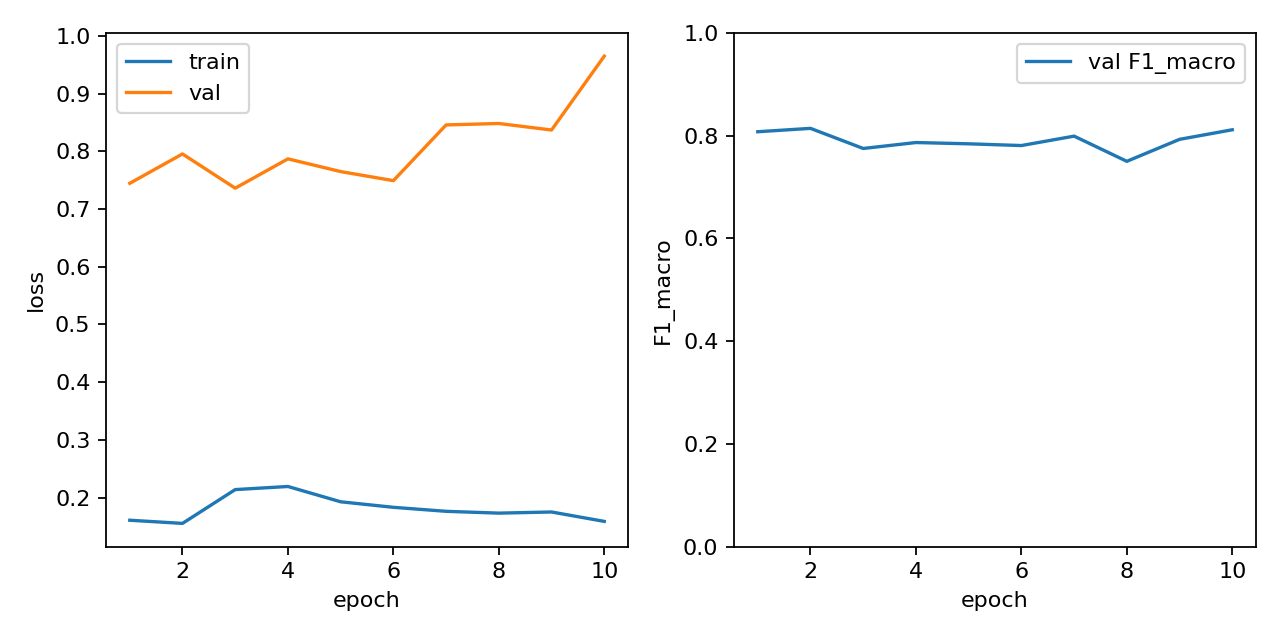

mobilenet_v3_small


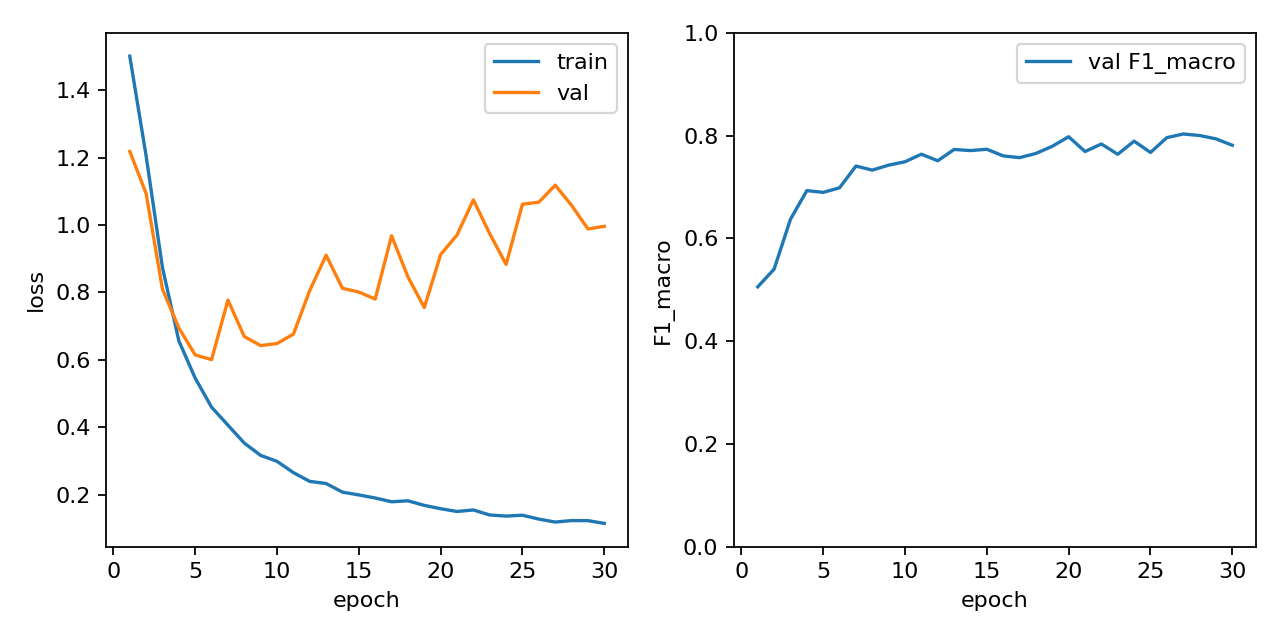

In [8]:
for model_name in ["scratch_resnet", "resnet18", "mobilenet_v3_small"]:
    print(model_name)
    display(DisplayImage(filename=str(ROOT / f"runs/{model_name}/learning_curves.png"), width=760))


## 5. Матрицы ошибок

scratch_resnet


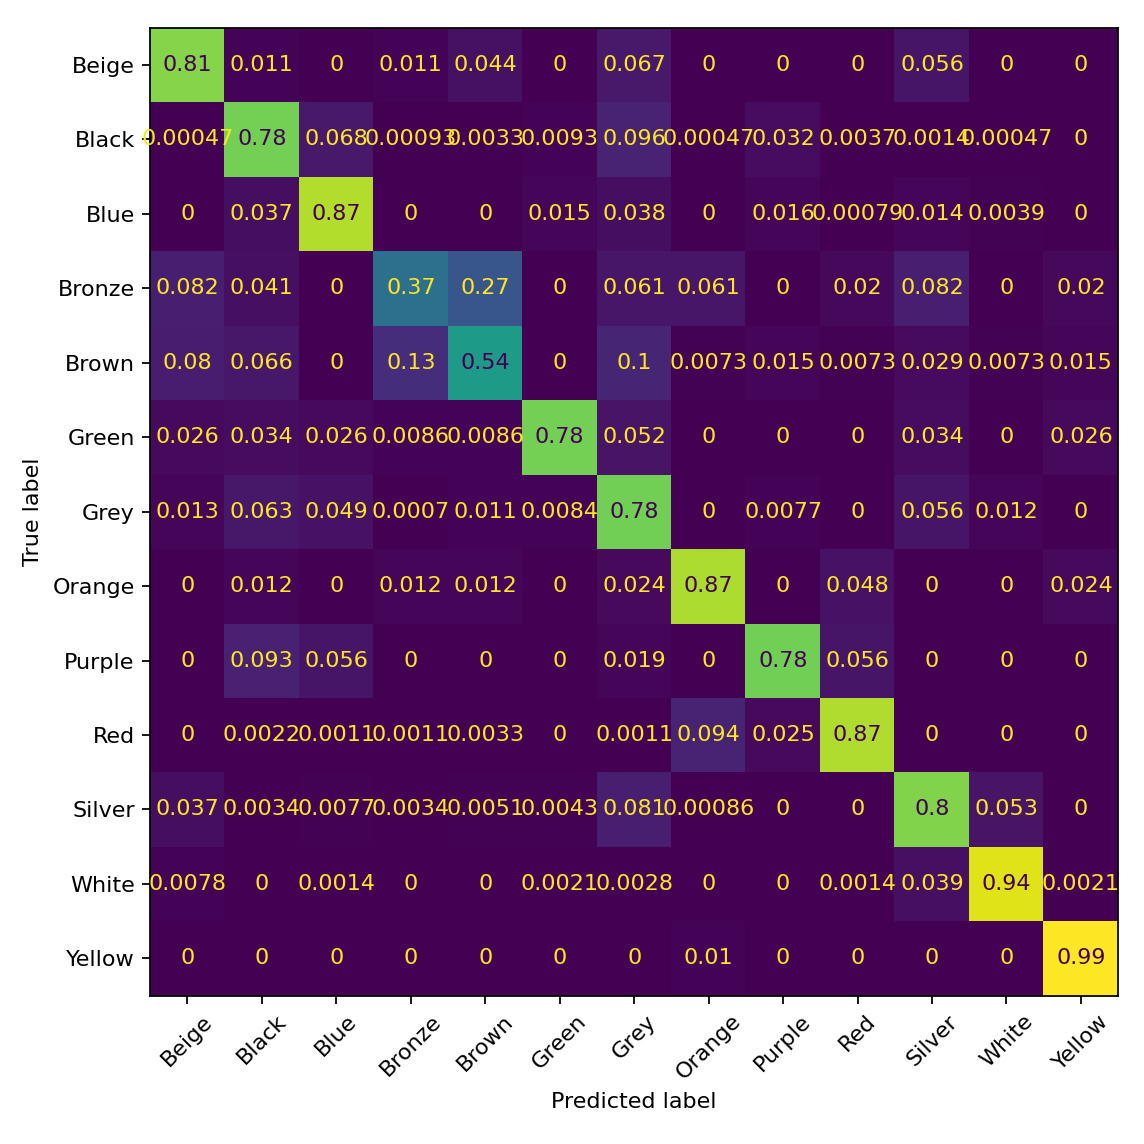

resnet18


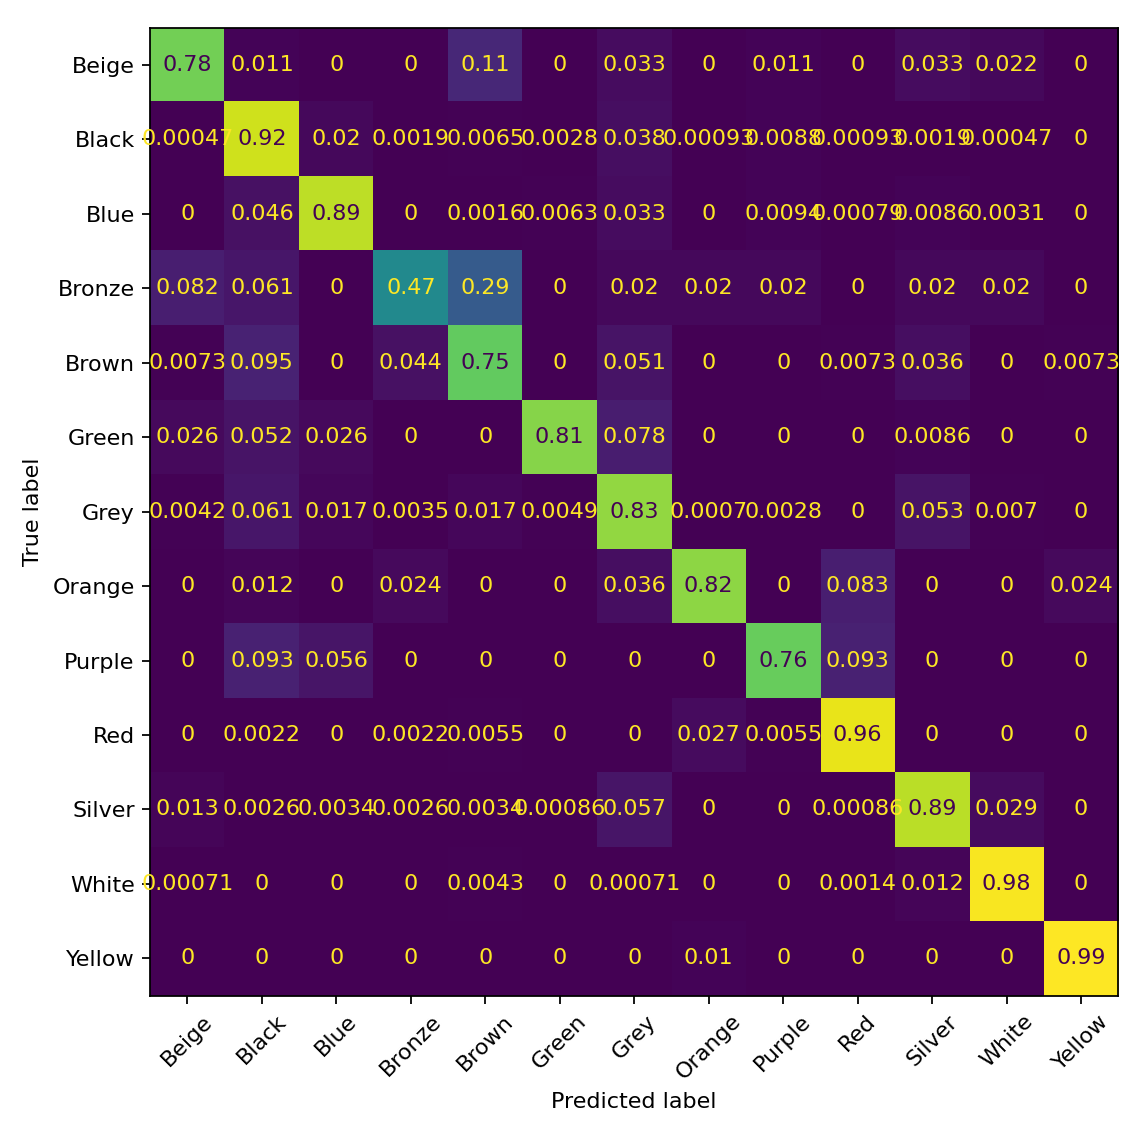

mobilenet_v3_small


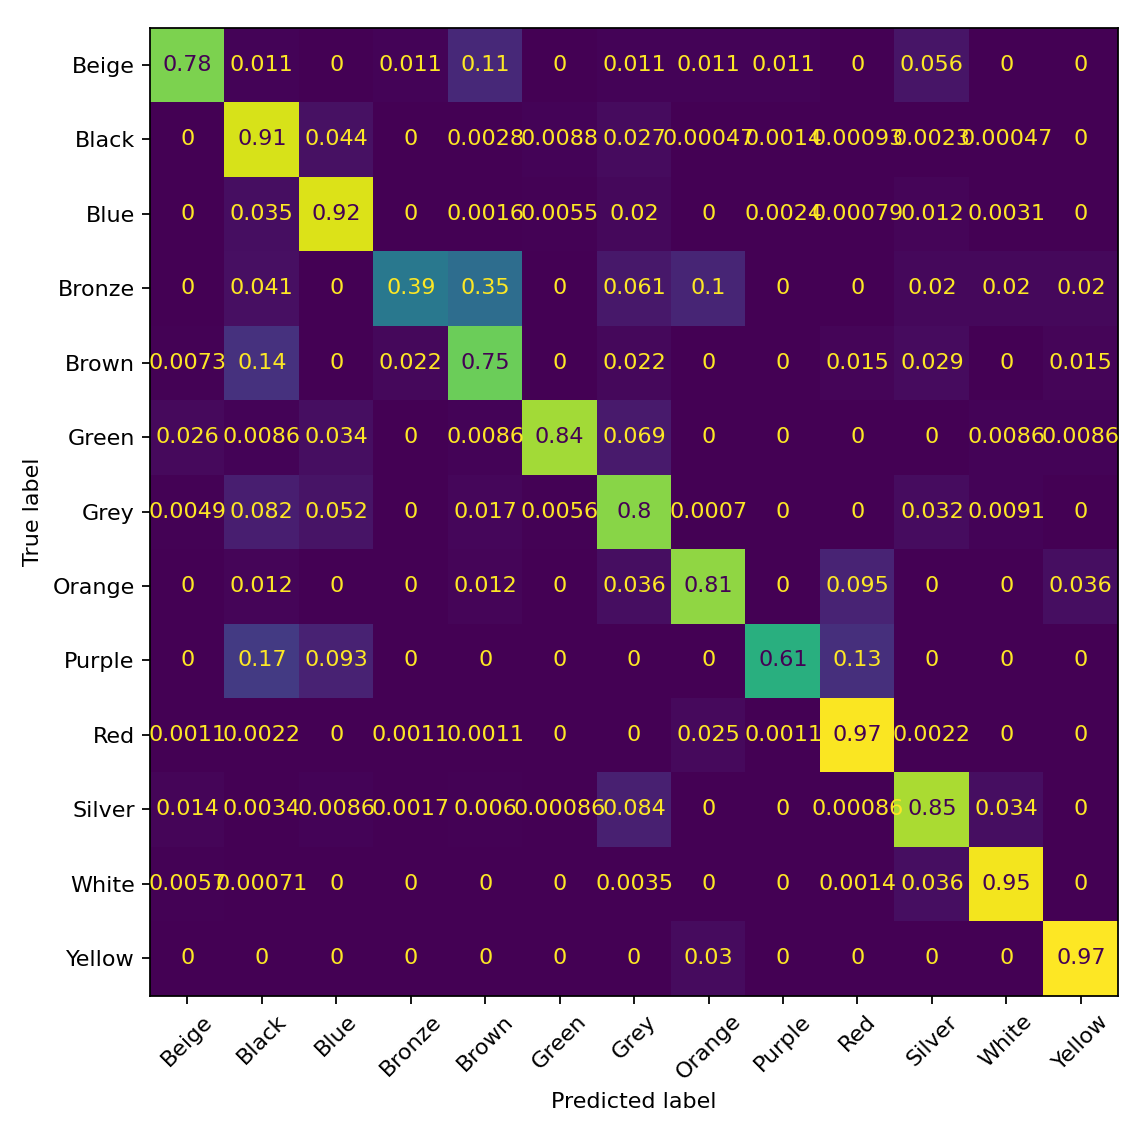

In [9]:
for model_name in ["scratch_resnet", "resnet18", "mobilenet_v3_small"]:
    print(model_name)
    display(DisplayImage(filename=str(ROOT / f"runs/{model_name}/confusion_matrix.png")))


## 6. Инференс ResNet-18

In [10]:
cmd = [
    sys.executable,
    str(ROOT / "main.py"),
    "predict-samples",
    "--checkpoint",
    str(ROOT / "runs/resnet18/best.pt"),
    "--manifest-dir",
    str(ROOT / "data/dvm_front"),
    "--out-dir",
    str(ROOT / "runs/resnet18/inference_demo"),
    "--num-samples",
    "16",
    "--device",
    "cuda" if torch.cuda.is_available() else "cpu",
]
print(" ".join(cmd))
subprocess.run(cmd, check=True)

T:\itmo\cv\cv_labs\.venv\Scripts\python.exe T:\itmo\cv\cv_labs\lab1\main.py predict-samples --checkpoint T:\itmo\cv\cv_labs\lab1\runs\resnet18\best.pt --manifest-dir T:\itmo\cv\cv_labs\lab1\data\dvm_front --out-dir T:\itmo\cv\cv_labs\lab1\runs\resnet18\inference_demo --num-samples 16 --device cuda


CompletedProcess(args=['T:\\itmo\\cv\\cv_labs\\.venv\\Scripts\\python.exe', 'T:\\itmo\\cv\\cv_labs\\lab1\\main.py', 'predict-samples', '--checkpoint', 'T:\\itmo\\cv\\cv_labs\\lab1\\runs\\resnet18\\best.pt', '--manifest-dir', 'T:\\itmo\\cv\\cv_labs\\lab1\\data\\dvm_front', '--out-dir', 'T:\\itmo\\cv\\cv_labs\\lab1\\runs\\resnet18\\inference_demo', '--num-samples', '16', '--device', 'cuda'], returncode=0)

In [11]:
predictions = pd.read_csv(ROOT / "runs/resnet18/inference_demo/predictions.csv")
predictions

,path,true_label,pred_label,confidence,correct
0,T:\itmo\cv\cv_labs\lab1\data\confirmed_fronts\...,Grey,Grey,0.851873,True
1,T:\itmo\cv\cv_labs\lab1\data\confirmed_fronts\...,Silver,Silver,0.999415,True
2,T:\itmo\cv\cv_labs\lab1\data\confirmed_fronts\...,Black,Black,0.991807,True
3,T:\itmo\cv\cv_labs\lab1\data\confirmed_fronts\...,Silver,Silver,0.956034,True
4,T:\itmo\cv\cv_labs\lab1\data\confirmed_fronts\...,White,White,0.999749,True
5,T:\itmo\cv\cv_labs\lab1\data\confirmed_fronts\...,Black,Black,0.985199,True
6,T:\itmo\cv\cv_labs\lab1\data\confirmed_fronts\...,Black,Black,0.994287,True
7,T:\itmo\cv\cv_labs\lab1\data\confirmed_fronts\...,Black,Black,0.974289,True
8,T:\itmo\cv\cv_labs\lab1\data\confirmed_fronts\...,Black,Black,0.869606,True
9,T:\itmo\cv\cv_labs\lab1\data\confirmed_fronts\...,Black,Black,0.999428,True


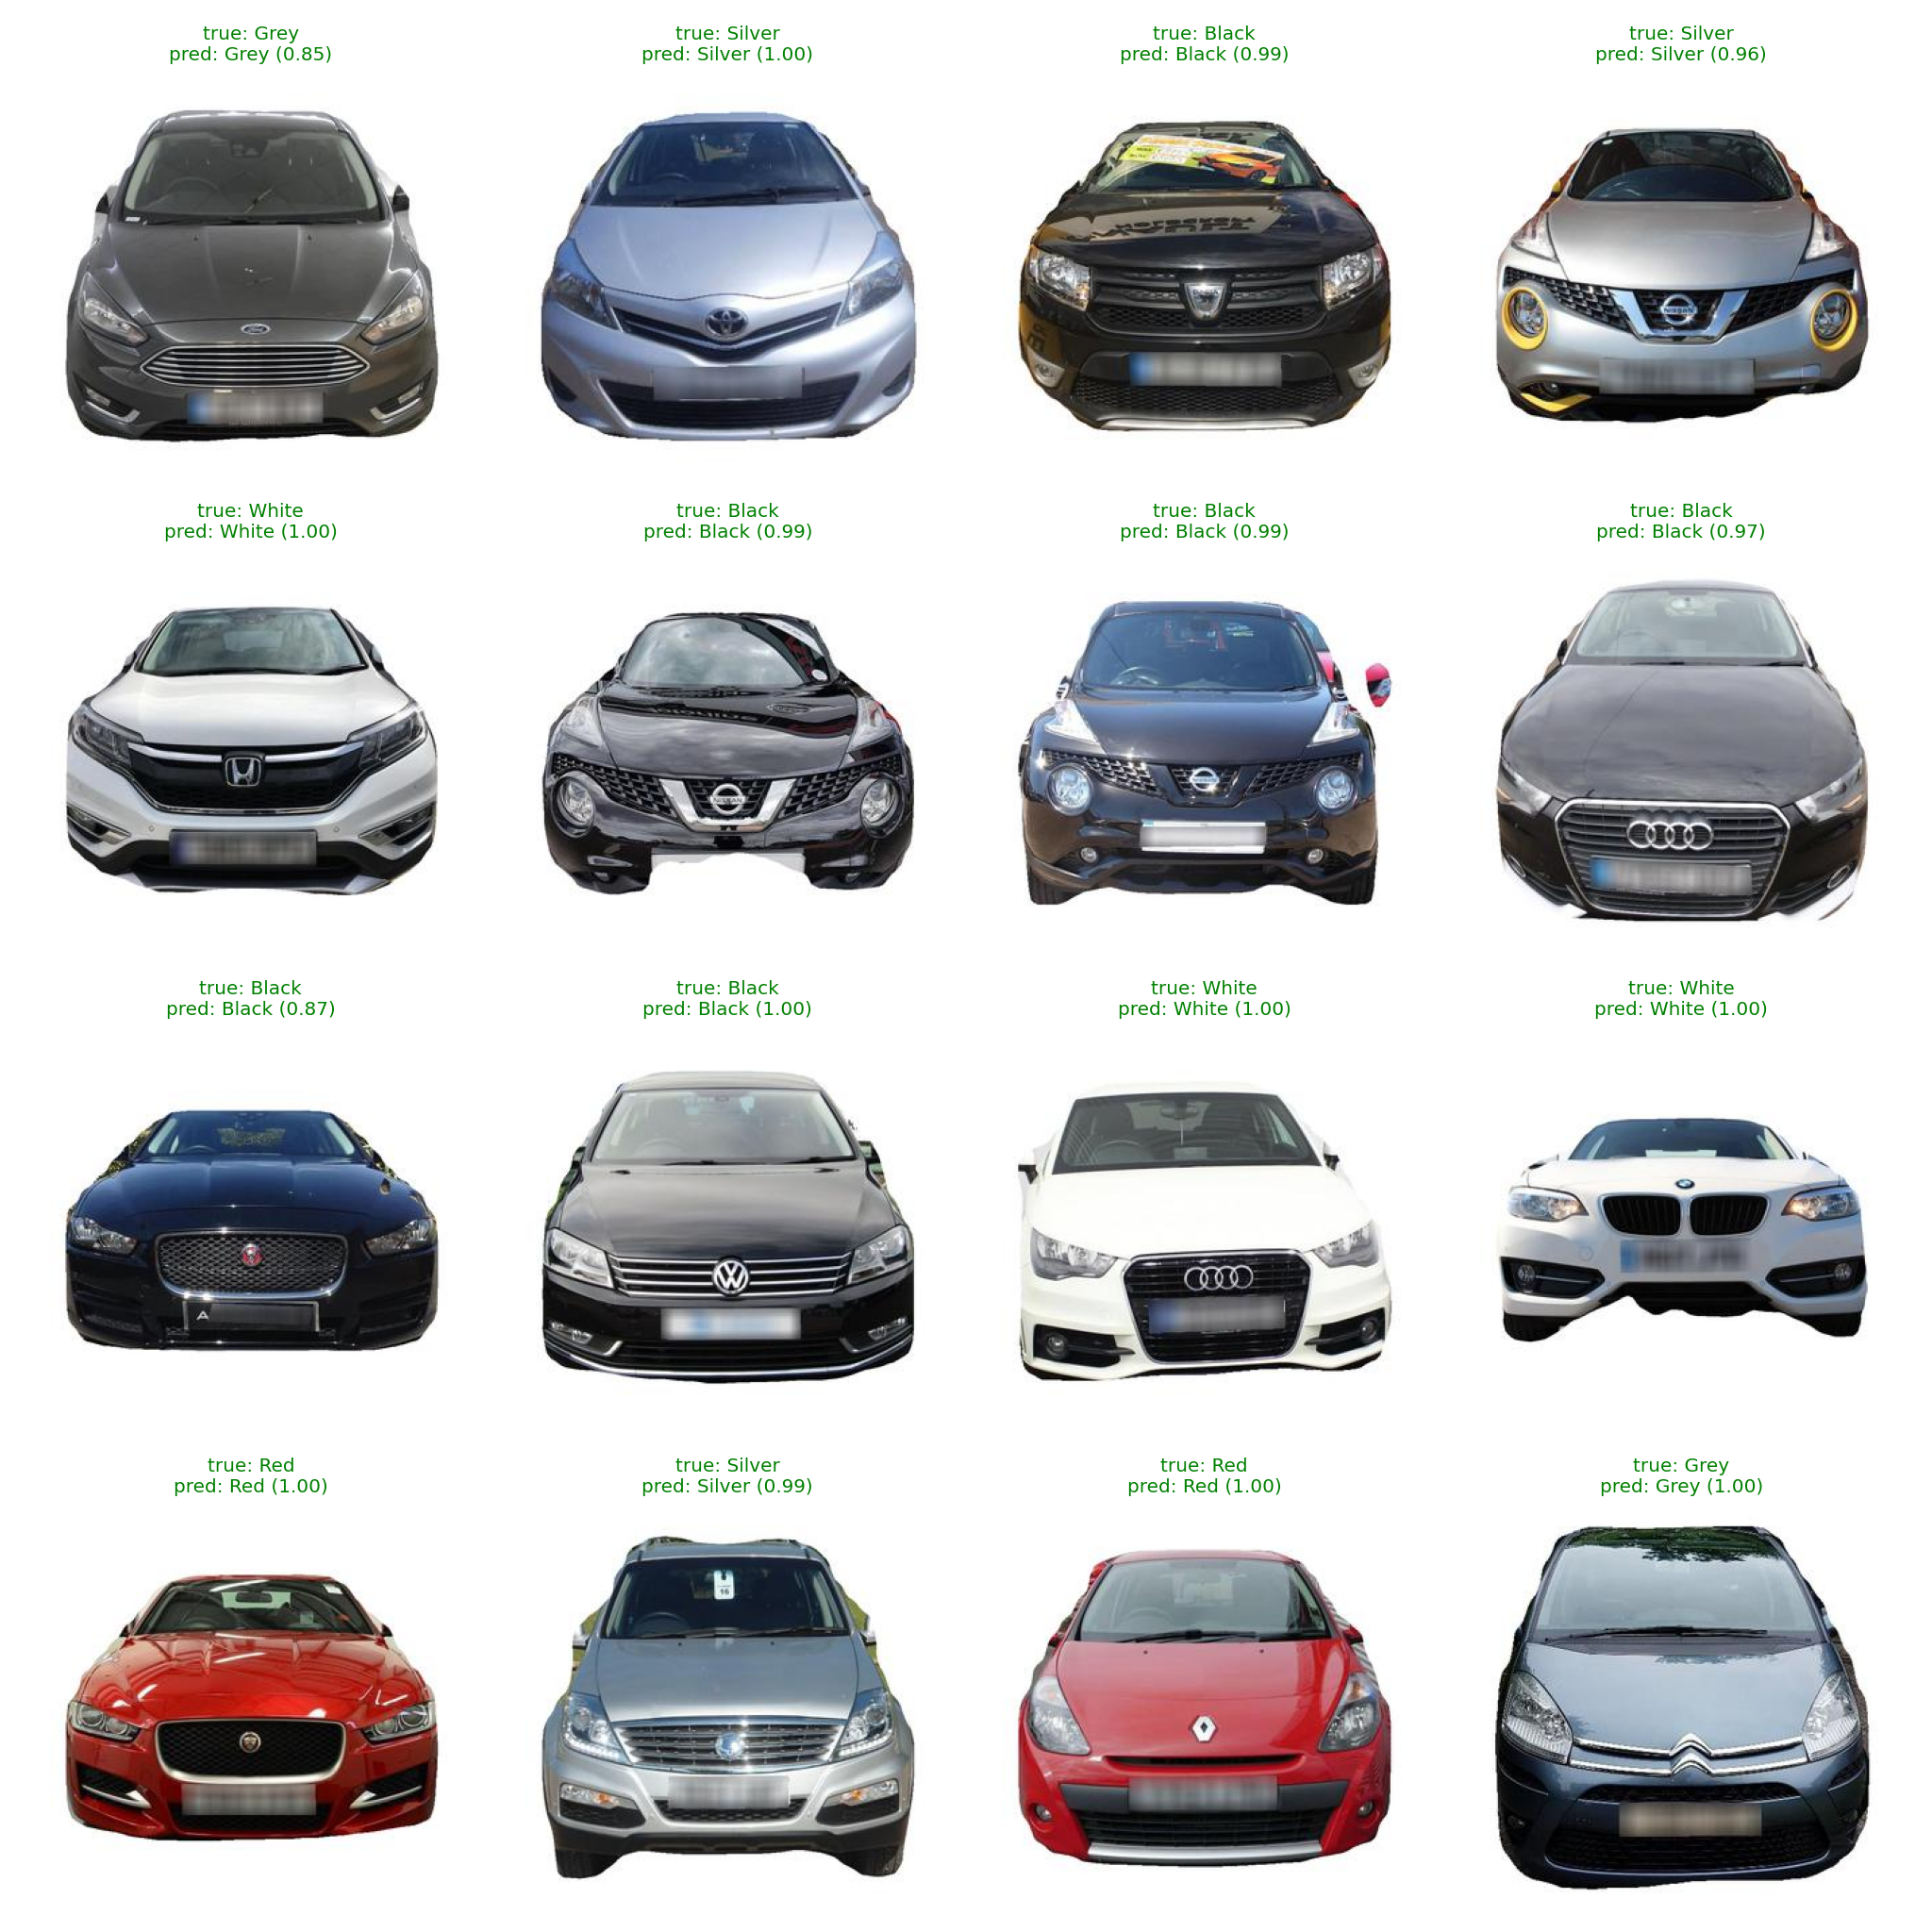

In [12]:
display(DisplayImage(filename=str(ROOT / "runs/resnet18/inference_demo/predictions_grid.png"), width=760))


## 7. Вывод

Лучшая модель - `ResNet-18`. Она получила test `F1_macro = 0.8085`, то есть требование лабораторной `F1_macro > 0.8` выполнено. Предобученные модели оказались лучше модели, обученной с нуля, потому что ImageNet-веса уже содержат полезные визуальные признаки.